In [3]:
import numpy as np
import gzip
import struct
import matplotlib.pyplot as plt
import random

# **Step 1 Data Acquisition and Visualization :**

***Import and read the data.***

In [4]:
def read_idx(filename) :
    with gzip.open(filename, 'rb') as f :
        zero, data_type, dims = struct.unpack('>HBB', f.read(4))
        shape = tuple(struct.unpack('>I', f.read(4))[0] for d in range(dims))
        return np.frombuffer(f.read(), dtype=np.uint8).reshape(shape)

In [9]:
train_img = read_idx('./MNIST/train-images-idx3-ubyte.gz').copy()
train_label = read_idx('./MNIST/train-labels-idx1-ubyte.gz').copy()
test_img = read_idx('./MNIST/t10k-images-idx3-ubyte.gz').copy()
y_test = read_idx('./MNIST/t10k-labels-idx1-ubyte.gz').copy()

In [10]:
print(train_img.shape)

(60000, 28, 28)


In [11]:
print(train_label.shape)

(60000,)


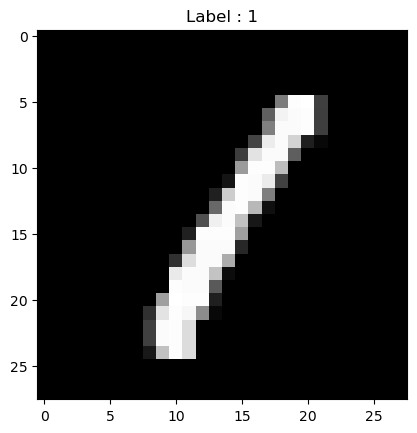

In [38]:
# Display the image of a chosen sample along with its label.
n = 3

plt.imshow(train_img[n], cmap = 'gray')
plt.title("Label : " + str(train_label[n]))
plt.show()

# **Step 2 Data Preprocessing :**

***Here we will preprocess the data by,***


*   ***Normalizing the pixel values of the image dataset to be between 0 and 1.***
*   ***One Hot Encode the training label dataset using the eye function of NumPy.***

In [13]:
# Normalize the training and testing image datasets
normalized_train_img = (1/255)*train_img

normalized_test_img = (1/255)*test_img

In [14]:
# One Hot Encode the training label dataset using the eye function
eye = np.eye(10, 10, 0)
ohe_train_lab = []

# For each label in the label dataset, append the corresponding row of the eye matrix to the empty list
for i in train_label :
  ohe_train_lab.append(eye[i])

y_train = np.array(ohe_train_lab)

In [15]:
# One Hot Encoded training label dataset
y_train.shape

(60000, 10)

In [16]:
# One Hot Encoding the testing label dataset in not necessary
y_test.shape

(10000,)

# **Step 3 Network Initialization :**

***Here we will,***

*   ***Identify the auxiliary input including the Sigmoid function and its derivative and Softmax function***
*   ***Define the derivative of sigmoid activation function.***
*   ***Flatten each 28x28 image to 784x1 array.***
*   ***Initialize matrices of random weights and biases of hidden layer 1 with 128 neurons.***
*   ***Initialize matrices of random weights and biases of hidden layer 2 with 64 neurons.***
*   ***Initialize matrices of random weights and biases of the output layer with 10 neurons.***


***Sigmoid function is given by,***

$\sigma\left(x\right)=\frac{1}{1+e^{-x}}$

In [17]:
# Define the sigmoid activation function
def sigmoid (x):
    return 1 / (1 + np.exp(-x))

***Derivative of sigmoid function is given by,***

$\sigma'\left(x\right)=\sigma\left(x\right)*\left(1-\sigma\left(x\right)\right)$

In [18]:
# Define the derivative of the sigmoid activation function
def sigmoid_d (x) :
  return sigmoid(x) * (1 - sigmoid(x))

***Softmax function is given by,***

$\sigma(z_i) = \frac{e^{z_{i}}}{\sum_{j=1}^K e^{z_{j}}} \ \ \ for\ i=1,2,\dots,K$

In [19]:
# Define the softmax activation function
def softmax (x):
  exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
  return exp_x / np.sum(exp_x, axis=1, keepdims=True)

In [20]:
# Flatten each image of the training image dataset from 28x28 matrix to 784x1 array.
flatten_norm_train_img = []

for i in range(len(normalized_train_img)) :
  flatten_norm_train_img.append(normalized_train_img[i].flatten())

X_train = np.array(flatten_norm_train_img)

In [21]:
# Flatten each image of the testing image dataset from 28x28 matrix to 784x1 array.
flatten_norm_test_img = []

for i in range(len(normalized_test_img)) :
  flatten_norm_test_img.append(normalized_test_img[i].flatten())

X_test = np.array(flatten_norm_test_img)

In [22]:
print("Final shape of image training dataset : ",  X_train.shape) # Normalized and Flattened
print("Final shape of label training dataset : ",  y_train.shape) # One Hot Encoded
print("Final shape of image testing dataset : ",  X_test.shape) # Normalized and Flattened
print("Final shape of label testing dataset : ",  y_test.shape) # No preprocessing required

Final shape of image training dataset :  (60000, 784)
Final shape of label training dataset :  (60000, 10)
Final shape of image testing dataset :  (10000, 784)
Final shape of label testing dataset :  (10000,)


In [25]:
def init_parameters() :

  # Set the random seed
  random.seed(695)

  # Initialize the weights for hidden layer 1 with small random values (scaled by 0.01)
  W1 = np.random.randn(784, 128) * 0.01
  # Initialize the biases for hidden layer 1 with random values
  b1 = np.random.randn(1, 128)

  # Initialize the weights for hidden layer 2 with small random values (scaled by 0.01)
  W2 = np.random.randn(128, 64) * 0.01
  # Initialize the biases for hidden layer 2 with random values
  b2 = np.random.randn(1, 64)

  # Initialize the weights for output layer with small random values (scaled by 0.01)
  W3 = np.random.randn(64, 10) * 0.01
  # Initialize the biases for output layer with random values
  b3 = np.random.randn(1, 10)

  return W1, b1, W2, b2, W3, b3

# **Step 4 Feed Forward :**


***In this section we will define a feed forward function that will calculate the outputs of each layer and their corresponding activation functions based on the given input, weights and biases.***

In [26]:
def feed_forward (x, W1, b1, W2, b2, W3, b3) :
  # Compute the linear combination of input, weights and biases for the first hidden layer
  Z1 = np.dot(x, W1) + b1
  # Apply the sigmoid activation function to the result of the first hidden layer
  A1 = sigmoid(Z1)
  # Compute the linear combination of input, weights and biases for the second hidden layer
  Z2 = np.dot(A1, W2) + b2
  # Apply the sigmoid activation function to the result of the second hidden layer
  A2 = sigmoid(Z2)
  # Compute the linear combination of input, weights and biases for the output layer
  Z3 = np.dot(A2, W3) + b3
  # Apply the softmax activation function to the result of the output layer
  A3 = softmax(Z3)

  return Z1, A1, Z2, A2, Z3, A3

# **Step 5 Back Propagation :**

***Here we will,***



*   ***Derive the equations for gradients and biases using the chain rule.***
*   ***Define a backpropagation function to calculate the gradients of the weights and biases.***
*   ***Define the categorical crosss entropy loss function, as provided in the problem statement.***

In [27]:
def back_prop (x, y, Z1, A1, W1, Z2, A2, W2, Z3, A3, W3) :

  # Compute the gradient of the loss with respect to Z3 (output layer)
  dZ3 = A3 - y
  # Compute the gradient of the loss with respect to weights W3
  dW3 = np.dot(A2.T, dZ3)
  # Compute the gradient of the loss with respect to bias b3
  db3 = np.sum(dZ3, axis = 0, keepdims=True)

  # Compute the gradient of the loss with respect to Z2 (second hidden layer)
  dZ2 = np.dot(dZ3, W3.T) * sigmoid_d(Z2)
  # Compute the gradient of the loss with respect to weights W2
  dW2 = np.dot(A1.T, dZ2)
  # Compute the gradient of the loss with respect to bias b2
  db2 = np.sum(dZ2, axis = 0, keepdims=True)

  # Compute the gradient of the loss with respect to Z1 (first hidden layer)
  dZ1 = np.dot(dZ2, W2.T) * sigmoid_d(Z1)
  # Compute the gradient of the loss with respect to weights W1
  dW1 = np.dot(x.T, dZ1)
  # Compute the gradient of the loss with respect to bias b1
  db1 = np.sum(dZ1, axis = 0, keepdims=True)


  return dW1, db1, dW2, db2, dW3, db3

In [28]:
def categorical_crossentropy (y_true, y_pred) :
  n_samples = y_true.shape[0]
  y_pred_clipped = np.clip(y_pred, 1e-12, 1 - 1e-12)
  return -np.sum(y_true * np.log(y_pred_clipped)) / n_samples

# **Step 6 Model Training :**

***In this section we will train the neural network using the Mini Batch Gradient Descent optimization algorithm on the given training dataset.***

***Through this we obtain the optimized values of the weights and biases of each layer of the neural network on the training dataset.***


In [30]:
def mini_batch_gradient_descent(X, y, learning_rate, batch_size, epochs):

  # Get the number of samples
  m, n = X.shape

  # Initialize weights and biases
  W1, b1, W2, b2, W3, b3 = init_parameters()

  # List to store loss values for each iteration
  loss_vals = []

  # Initialize the iteration counter
  iter = 0

  for epoch in range(epochs):
    # Shuffle the data
    indices = np.random.permutation(m)
    X = X[indices]
    y = y[indices]

    # Iterate over mini-batches
    for i in range(0, m, batch_size):
      X_batch = X[i:i + batch_size]
      y_batch = y[i:i + batch_size]


      # Feed-forward pass to calculate the outputs for the mini-batch
      Z1, A1, Z2, A2, Z3, A3 = feed_forward(X_batch, W1, b1, W2, b2, W3, b3)

      # Compute the loss for this iteration
      loss = categorical_crossentropy(y_batch, A3)

      if iter % 1000 == 0 :
        print("Loss at iteration " + str(iter) + " is : " + str(loss))

      loss_vals.append(loss)

      # Compute gradients for weights and biases using backpropagation
      dW1, db1, dW2, db2, dW3, db3 = back_prop(X_batch, y_batch, Z1, A1, W1, Z2, A2, W2, Z3, A3, W3)

      # Update the weights and biases using the gradients and the learning rate
      W1 -= learning_rate * dW1
      b1 -= learning_rate * db1
      W2 -= learning_rate * dW2
      b2 -= learning_rate * db2
      W3 -= learning_rate * dW3
      b3 -= learning_rate * db3

      iter += 1


  return W1, b1, W2, b2, W3, b3, loss_vals

In [31]:
W1, b1, W2, b2, W3, b3, loss_vals = mini_batch_gradient_descent(X_train, y_train, learning_rate = 0.01, batch_size = 128, epochs = 100)

Loss at iteration 0 is : 2.800223652285843
Loss at iteration 1000 is : 0.29123334250254607
Loss at iteration 2000 is : 0.15354146898815957
Loss at iteration 3000 is : 0.09395238875387284
Loss at iteration 4000 is : 0.10899129249260588
Loss at iteration 5000 is : 0.021400251420735872
Loss at iteration 6000 is : 0.02388788008039087
Loss at iteration 7000 is : 0.06436363970650033
Loss at iteration 8000 is : 0.014854318751270634
Loss at iteration 9000 is : 0.016430185818777792
Loss at iteration 10000 is : 0.013210121081271089
Loss at iteration 11000 is : 0.007952028532547633
Loss at iteration 12000 is : 0.004357692777695913
Loss at iteration 13000 is : 0.008235217706672345
Loss at iteration 14000 is : 0.0058684424329826755
Loss at iteration 15000 is : 0.004537294518482595
Loss at iteration 16000 is : 0.002629580609103963
Loss at iteration 17000 is : 0.0011626138875948425
Loss at iteration 18000 is : 0.0017447977926849402
Loss at iteration 19000 is : 0.0008092371544054913
Loss at iteration 

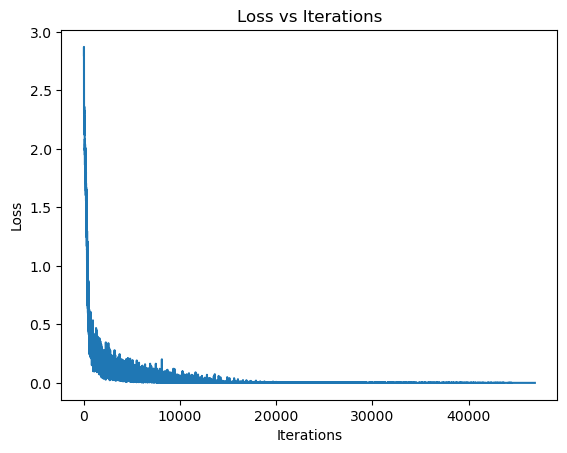

In [32]:
# Plot the loss for each iteration

x = [i for i in range(len(loss_vals))]
plt.plot(x, loss_vals)
plt.title("Loss vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Loss")


plt.show()

# **Step 7 Model Evaluation :**


***In this section we will evaluate the trained neural network by measuring its accuracy on the training dataset and the testing dataset.***

In [33]:
def predict(X, W1, b1, W2, b2, W3, b3):

  # Perform a forward pass through the entire neural network
  Z1, A1, Z2, A2, Z3, predictions = feed_forward(X, W1, b1, W2, b2, W3, b3)

  # Return the class with the highest predicted probability
  return np.argmax(predictions, axis = 1)

In [34]:
def accuracy(predictions, Y):
  # Return the ratio of correct predictions
  return np.sum(predictions == Y) / Y.size

In [35]:
# Generate predictions for the training dataset using the trained model
train_predictions = predict(X_train, W1, b1, W2, b2, W3, b3)
# Calculate the accuracy of the model on the training dataset
train_accuracy = accuracy(train_predictions, train_label)
print("Train Accuracy : ", train_accuracy)

# Generate predictions for the testing dataset using the trained model
test_predictions = predict(X_test, W1, b1, W2, b2, W3, b3)
# Calculate the accuracy of the model on the testing dataset
test_accuracy = accuracy(test_predictions, y_test)
print("Test Accuracy : ", test_accuracy)

Train Accuracy :  1.0
Test Accuracy :  0.9792


In [36]:
# Initialize an empty list to store the indices of misclassified samples
misclassified = []


for i in range(len(X_test)) :
  # Make a prediction for the current test sample and if the prediction is not equal to the true label, mark it as misclassified
  if predict(X_test[i], W1, b1, W2, b2, W3, b3) != y_test[i] :
    misclassified.append(i)

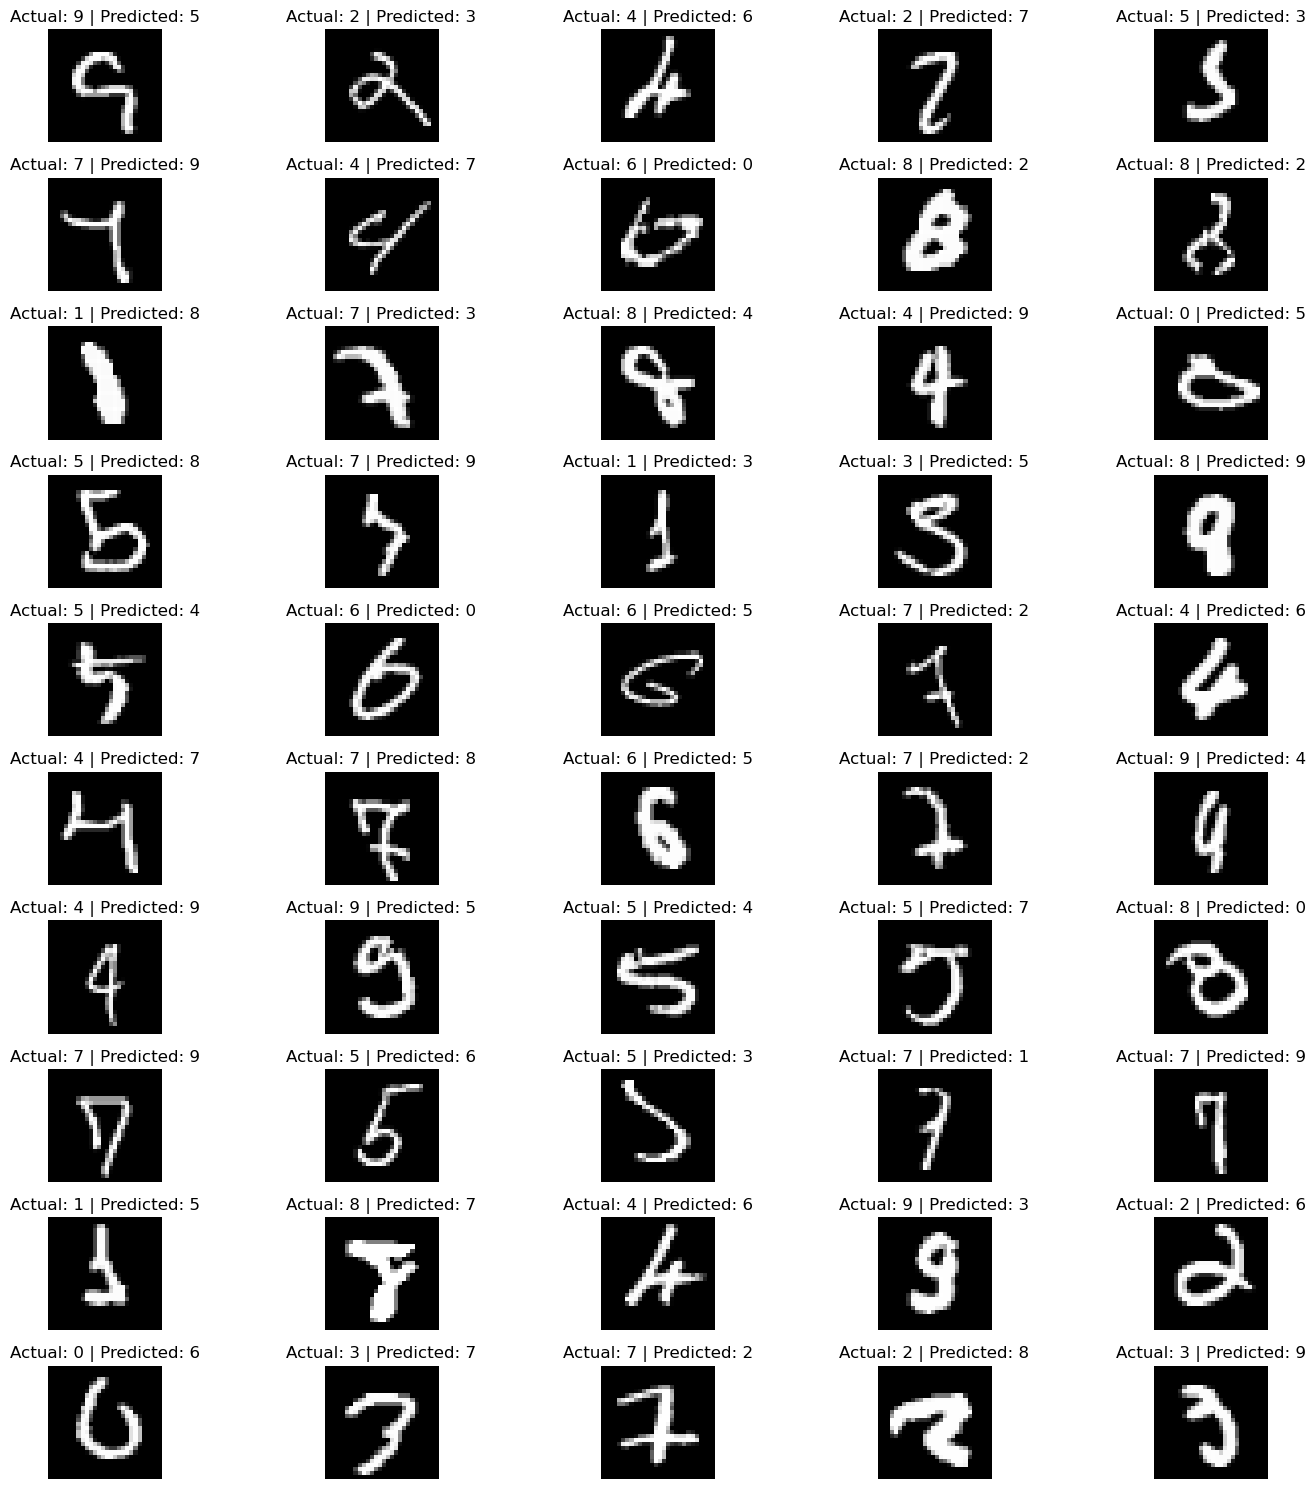

In [37]:
# Create a figure with 10 rows and 5 columns of subplots i.e. 50 misclassified samples
fig, axes = plt.subplots(10, 5, figsize=(15, 15))

# Loop through each subplot
for i, ax in enumerate(axes.flat) :
  # Turn off the axis lines and ticks for a cleaner display of images
  ax.set_axis_off()
  # Display the grayscale image
  ax.imshow(test_img[misclassified[i]], cmap = 'gray')
  # Set the title of each subplot
  ax.set_title("Actual: " + str(y_test[misclassified[i]]) + " | Predicted: " + str(predict(X_test[misclassified[i]], W1, b1, W2, b2, W3, b3)[0]))

plt.tight_layout()
plt.show()

# **Insights :**

***From the above, it seems that the model is not able to classify the images that are not written clearly, in some cases the numbers are difficult for human reader too.***  